In [ ]:
!pip install mediapipe scikit-learn opencv-python-headless matplotlib seaborn -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 48.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 7.0 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             ConfusionMatrixDisplay, classification_report)
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance

print('Done')

Done


In [ ]:
from google.colab import files
uploaded = files.upload()  # Upload gesture_data.csv

df = pd.read_csv('gesture_data_combined.csv')

print(f'Shape  : {df.shape}')
print(f'Classes: {df["label"].unique()}')
print(f'Nulls  : {df.isnull().sum().sum()}')
print()
print('Phân bố class:')
print(df['label'].value_counts())

Saving gesture_data_combined.csv to gesture_data_combined (1).csv
Shape  : (11114, 64)
Classes: ['2finger' 'fist' '4finger' '3finger' 'open' 'point']
Nulls  : 0

Phân bố class:
label
point      1937
2finger    1880
3finger    1843
open       1840
4finger    1813
fist       1801
Name: count, dtype: int64


In [ ]:
FEATURE_COLS = [f'{ax}{i}' for i in range(21) for ax in ['x','y','z']]
CLASSES      = sorted(df['label'].unique())

X = df[FEATURE_COLS].values
y = df['label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y        # giữ tỷ lệ class đều nhau
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train,
    test_size=0.15,
    random_state=42,
    stratify=y_train
)

print(f'Train : {X_train.shape[0]} mẫu')
print(f'Val   : {X_val.shape[0]} mẫu')
print(f'Test  : {X_test.shape[0]} mẫu')
print(f'\nFeatures: {X_train.shape[1]} chiều')

Train : 7557 mẫu
Val   : 1334 mẫu
Test  : 2223 mẫu

Features: 63 chiều


In [ ]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svc',    SVC(probability=True, random_state=42))
])

param_grid = {
    'svc__C'     : [0.1, 1, 10, 100],
    'svc__gamma' : ['scale', 'auto', 0.001, 0.01],
    'svc__kernel': ['rbf', 'poly']
}

print('Đang GridSearch tìm C và gamma tối ưu...')
grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)
grid.fit(X_train, y_train)

best_model = grid.best_estimator_

print(f'\n Best params : {grid.best_params_}')
print(f'   Best CV acc : {grid.best_score_*100:.2f}%')

Đang GridSearch tìm C và gamma tối ưu...
Fitting 5 folds for each of 32 candidates, totalling 160 fits

 Best params : {'svc__C': 100, 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}
   Best CV acc : 98.98%


In [ ]:
# Val set
val_acc = accuracy_score(y_val, best_model.predict(X_val))
print(f'Val Accuracy : {val_acc*100:.2f}%')

# Cross-validation
X_tv      = np.vstack([X_train, X_val])
y_tv      = np.concatenate([y_train, y_val])
cv_scores = cross_val_score(best_model, X_tv, y_tv, cv=5)
print(f'Cross-val    : {cv_scores.mean()*100:.2f}% ± {cv_scores.std()*100:.2f}%')

# Test set
y_pred   = best_model.predict(X_test)
test_acc = accuracy_score(y_test, y_pred)
print(f'Test Accuracy: {test_acc*100:.2f}%')

print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=CLASSES))

Val Accuracy : 98.65%
Cross-val    : 99.07% ± 0.15%
Test Accuracy: 98.74%

Classification Report:
              precision    recall  f1-score   support

     2finger       0.98      0.99      0.98       376
     3finger       0.99      0.98      0.98       369
     4finger       0.98      0.99      0.99       363
        fist       0.98      0.99      0.99       360
        open       1.00      0.98      0.99       368
       point       0.99      0.99      0.99       387

    accuracy                           0.99      2223
   macro avg       0.99      0.99      0.99      2223
weighted avg       0.99      0.99      0.99      2223



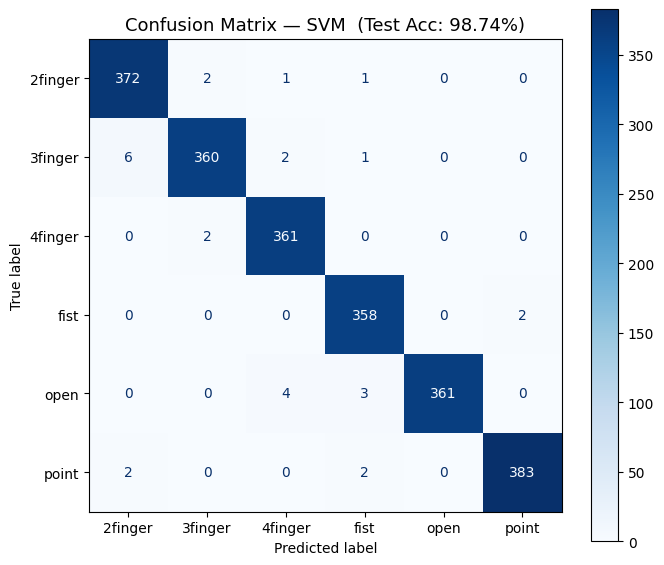

In [ ]:
cm   = confusion_matrix(y_test, y_pred, labels=CLASSES)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASSES)

fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(cmap='Blues', ax=ax)
ax.set_title(f'Confusion Matrix — SVM  (Test Acc: {test_acc*100:.2f}%)',
             fontsize=13)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

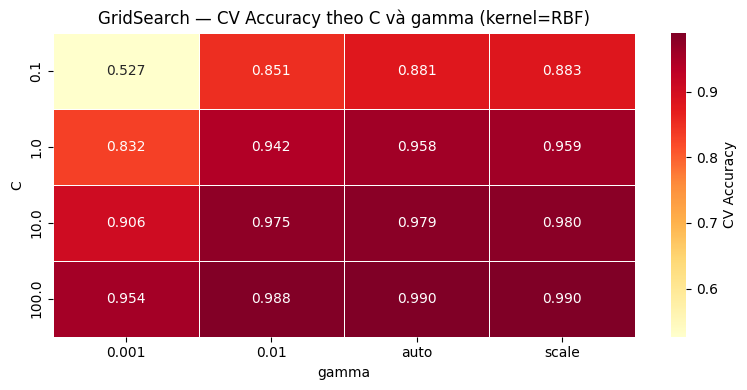

In [ ]:
# Visualize GridSearch results (chỉ kernel RBF)
results = pd.DataFrame(grid.cv_results_)
rbf     = results[results['param_svc__kernel'] == 'rbf'].copy()

rbf['C']     = rbf['param_svc__C'].astype(str)
rbf['gamma'] = rbf['param_svc__gamma'].astype(str)

pivot = rbf.pivot_table(
    index='C', columns='gamma',
    values='mean_test_score'
)

plt.figure(figsize=(8, 4))
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label': 'CV Accuracy'})
plt.title('GridSearch — CV Accuracy theo C và gamma (kernel=RBF)')
plt.tight_layout()
plt.savefig('gridsearch_heatmap.png', dpi=150)
plt.show()

Đang tính permutation importance...


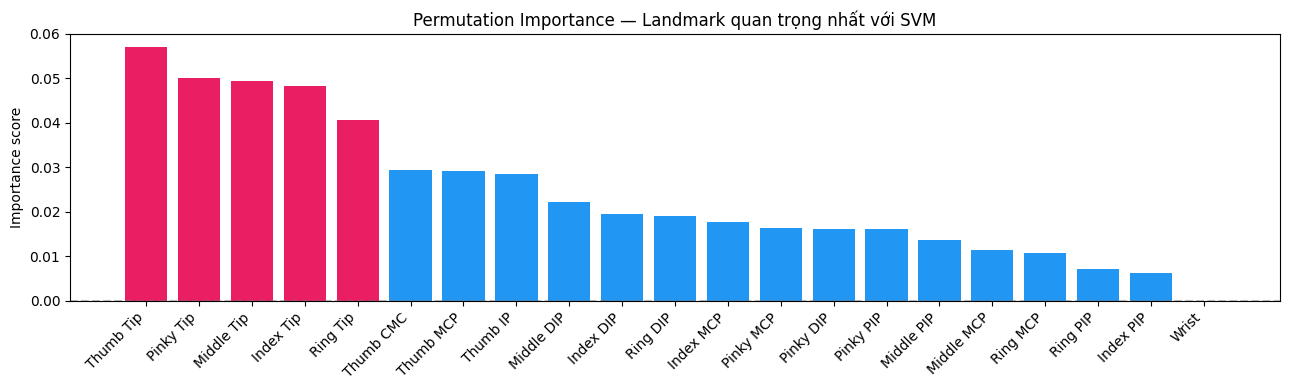

Top 5 landmark quan trọng nhất:
  1. Thumb Tip       0.0572
  2. Pinky Tip       0.0501
  3. Middle Tip      0.0494
  4. Index Tip       0.0482
  5. Ring Tip        0.0405


In [ ]:
print('Đang tính permutation importance...')
perm = permutation_importance(
    best_model, X_test, y_test,
    n_repeats=15, random_state=42, n_jobs=-1
)

# Gom theo landmark (mỗi landmark = 3 features x,y,z)
LANDMARK_NAMES = [
    'Wrist',
    'Thumb CMC','Thumb MCP','Thumb IP','Thumb Tip',
    'Index MCP','Index PIP','Index DIP','Index Tip',
    'Middle MCP','Middle PIP','Middle DIP','Middle Tip',
    'Ring MCP','Ring PIP','Ring DIP','Ring Tip',
    'Pinky MCP','Pinky PIP','Pinky DIP','Pinky Tip'
]

lm_imp = [perm.importances_mean[i*3:(i+1)*3].mean() for i in range(21)]

# Sort theo importance
sorted_idx  = np.argsort(lm_imp)[::-1]
sorted_names = [LANDMARK_NAMES[i] for i in sorted_idx]
sorted_imp   = [lm_imp[i] for i in sorted_idx]

colors = ['#E91E63' if i < 5 else '#2196F3' for i in range(21)]

plt.figure(figsize=(13, 4))
plt.bar(sorted_names, sorted_imp, color=colors)
plt.xticks(rotation=45, ha='right')
plt.title('Permutation Importance — Landmark quan trọng nhất với SVM')
plt.ylabel('Importance score')
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('landmark_importance.png', dpi=150)
plt.show()

print('Top 5 landmark quan trọng nhất:')
for i in range(5):
    print(f'  {i+1}. {sorted_names[i]:<15} {sorted_imp[i]:.4f}')

In [ ]:
with open('svm_gesture.pkl', 'wb') as f:
    pickle.dump(best_model, f)

print('Đã lưu: svm_gesture.pkl')
print(f'   Test Accuracy : {test_acc*100:.2f}%')
print(f'   Best params   : {grid.best_params_}')

# Download về máy
from google.colab import files as colab_files
colab_files.download('svm_gesture.pkl')
colab_files.download('confusion_matrix.png')
colab_files.download('landmark_importance.png')
colab_files.download('gridsearch_heatmap.png')

Đã lưu: svm_gesture.pkl
   Test Accuracy : 98.74%
   Best params   : {'svc__C': 100, 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Test với vài mẫu ngẫu nhiên từ test set
np.random.seed(0)
idx = np.random.choice(len(X_test), 10, replace=False)

print('Sample predictions:')
print(f'{"True":<12} {"Pred":<12} {"Confidence":<12} {"OK?"}')
print('-' * 45)
for i in idx:
    x     = X_test[i].reshape(1, -1)
    pred  = best_model.predict(x)[0]
    conf  = best_model.predict_proba(x).max()
    true  = y_test[i]
    ok    = '✅' if pred == true else '❌'
    print(f'{true:<12} {pred:<12} {conf:.2%}        {ok}')

Sample predictions:
True         Pred         Confidence   OK?
---------------------------------------------
fist         fist         99.28%        ✅
4finger      4finger      99.98%        ✅
3finger      3finger      99.14%        ✅
fist         fist         99.67%        ✅
point        point        93.95%        ✅
fist         fist         99.63%        ✅
open         open         99.74%        ✅
2finger      2finger      99.97%        ✅
open         open         100.00%        ✅
4finger      4finger      99.46%        ✅
